# Neighbor-Beam Tracking Baseline

This notebook implements a simple non-RL beam tracking baseline:

1. Start from the current selected beam.
2. Probe local neighbor beams.
3. Select the beam with the highest instantaneous SNR.
4. Log SNR, outage, blockage, selected beam, and oracle nearest beam.
5. Repeat until the episode ends.

This gives a sanity-check baseline to compare against PPO. This version runs the baseline with stochastic UE movement by default.

## Imports
Run this notebook from the project root so that `beam_tracker_rl` is importable.

In [1]:
from __future__ import annotations

import csv
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from beam_tracker_rl.env import BeamTrackingEnv
from beam_tracker_rl.sim import (
    MovementConfig,
    advance_ue_state,
    angle_error_deg,
    beam_angle_from_action,
    compute_snr,
    euclidean_distance,
    is_blocked,
    nearest_beam_index,
    true_angle_deg,
)

## Helper functions

In [2]:
def local_candidate_indices(center_idx: int, radius: int, num_beams: int) -> list[int]:
    """Return clipped local beam candidates around the current beam."""
    lo = max(0, int(center_idx) - int(radius))
    hi = min(int(num_beams) - 1, int(center_idx) + int(radius))
    return list(range(lo, hi + 1))


def probe_snr_at_current_state(env: BeamTrackingEnv, action: int) -> float:
    """
    Compute the SNR that would be observed if `action` were probed
    at the current UE position.

    This is an optimistic local-probing baseline because it uses simulator
    geometry to query the instantaneous SNR for each neighbor beam.
    """
    if env.ue_state is None:
        raise RuntimeError("env.reset() must be called before probing.")

    ue_xy = (env.ue_state.x, env.ue_state.y)
    theta_true = true_angle_deg(env.scenario.bs_xy, ue_xy)
    distance = euclidean_distance(env.scenario.bs_xy, ue_xy)
    blocked = is_blocked(env.scenario.bs_xy, ue_xy, env.scenario.obstacles)
    beam_deg = beam_angle_from_action(action, env.codebook)

    snr_parts = compute_snr(
        distance=distance,
        angle_error=angle_error_deg(theta_true, beam_deg),
        blocked=blocked,
        channel=env.channel_config,
    )
    return float(snr_parts["snr_db"])


def choose_best_neighbor_beam(
    env: BeamTrackingEnv,
    current_action: int,
    radius: int = 1,
) -> tuple[int, dict[int, float]]:
    """Probe current beam +/- radius and choose the candidate with max SNR."""
    candidates = local_candidate_indices(
        center_idx=current_action,
        radius=radius,
        num_beams=len(env.codebook),
    )

    candidate_snrs = {
        int(a): probe_snr_at_current_state(env, int(a))
        for a in candidates
    }

    best_action = max(candidate_snrs, key=candidate_snrs.get)
    return int(best_action), candidate_snrs

## Run neighbor-beam tracker

In [3]:
def run_neighbor_tracker(
    scenario_name: str = "single_occluder",
    max_steps: int = 192,
    num_beams: int = 13,
    radius: int = 1,
    seed: int = 0,
    movement_config: MovementConfig | None = None,
) -> tuple[list[dict[str, Any]], dict[str, float]]:
    """
    Run the local neighbor-probing baseline.

    Time convention:
        The baseline selects a beam using local probes at the current UE
        position, records SNR/reward, then advances the UE.
    """
    env = BeamTrackingEnv(
        scenario_name=scenario_name,
        max_steps=max_steps,
        num_beams=num_beams,
        movement_config=movement_config,
    )

    _, reset_info = env.reset(seed=seed)

    current_action = int(reset_info["selected_beam_idx"])
    env.current_action = current_action

    logs: list[dict[str, Any]] = []

    while env.ue_state is not None and env.ue_state.t < env.scenario.max_steps:
        prev_action = current_action

        action, candidate_snrs = choose_best_neighbor_beam(
            env=env,
            current_action=current_action,
            radius=radius,
        )

        # Evaluate the selected beam at the current UE position.
        # This keeps the baseline consistent with the environment reward,
        # outage, and event definitions.
        info, obs = env._evaluate(action=action, prev_action=prev_action)

        theta_true = float(info["true_angle_deg"])
        oracle_action = nearest_beam_index(theta_true, env.codebook)

        row = dict(info)
        row["candidate_snrs_db"] = dict(candidate_snrs)
        row["oracle_beam_idx"] = int(oracle_action)
        row["oracle_beam_deg"] = float(beam_angle_from_action(oracle_action, env.codebook))
        row["tracking_error_deg"] = float(
            abs(angle_error_deg(theta_true, float(info["selected_beam_deg"])))
        )
        logs.append(row)

        # Keep env state coherent.
        env.current_action = int(action)
        env.current_obs = obs
        env.prev_blocked = bool(info["blocked"])
        env.prev_outage = bool(info["outage"])
        current_action = int(action)

        # Advance UE after the decision epoch with the same RNG path as env.step().
        env.ue_state = advance_ue_state(
            env.ue_state,
            env.scenario,
            env.movement_config,
            env.np_random,
        )

    metrics = summarize_logs(logs)
    return logs, metrics


def summarize_logs(logs: list[dict[str, Any]]) -> dict[str, float]:
    if not logs:
        return {}

    snr = np.asarray([float(row["snr_db"]) for row in logs], dtype=float)
    outage = np.asarray([bool(row["outage"]) for row in logs], dtype=bool)
    blocked = np.asarray([bool(row["blocked"]) for row in logs], dtype=bool)
    reward = np.asarray([float(row["reward"]) for row in logs], dtype=float)
    beam = np.asarray([int(row["selected_beam_idx"]) for row in logs], dtype=int)
    err = np.asarray([float(row["tracking_error_deg"]) for row in logs], dtype=float)

    return {
        "steps": float(len(logs)),
        "mean_snr_db": float(np.mean(snr)),
        "p05_snr_db": float(np.percentile(snr, 5)),
        "min_snr_db": float(np.min(snr)),
        "outage_fraction": float(np.mean(outage)),
        "blocked_fraction": float(np.mean(blocked)),
        "beam_switch_count": float(np.sum(beam[1:] != beam[:-1])) if len(beam) > 1 else 0.0,
        "mean_reward": float(np.mean(reward)),
        "mean_tracking_error_deg": float(np.mean(err)),
        "p95_tracking_error_deg": float(np.percentile(err, 95)),
    }

## Plotting and CSV export

In [4]:
def write_csv(logs: list[dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = [
        "t",
        "ue_x",
        "ue_y",
        "ue_vx",
        "ue_vy",
        "ue_speed",
        "true_angle_deg",
        "selected_beam_idx",
        "selected_beam_deg",
        "oracle_beam_idx",
        "oracle_beam_deg",
        "tracking_error_deg",
        "distance",
        "blocked",
        "outage",
        "snr_db",
        "beam_gain_db",
        "path_loss_db",
        "blockage_loss_db",
        "reward",
    ]

    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for row in logs:
            ue_x, ue_y = row["ue_xy"]
            ue_vx, ue_vy = row["ue_velocity_xy"]
            writer.writerow(
                {
                    "t": row["t"],
                    "ue_x": ue_x,
                    "ue_y": ue_y,
                    "ue_vx": ue_vx,
                    "ue_vy": ue_vy,
                    "ue_speed": row["ue_speed"],
                    "true_angle_deg": row["true_angle_deg"],
                    "selected_beam_idx": row["selected_beam_idx"],
                    "selected_beam_deg": row["selected_beam_deg"],
                    "oracle_beam_idx": row["oracle_beam_idx"],
                    "oracle_beam_deg": row["oracle_beam_deg"],
                    "tracking_error_deg": row["tracking_error_deg"],
                    "distance": row["distance"],
                    "blocked": row["blocked"],
                    "outage": row["outage"],
                    "snr_db": row["snr_db"],
                    "beam_gain_db": row["beam_gain_db"],
                    "path_loss_db": row["path_loss_db"],
                    "blockage_loss_db": row["blockage_loss_db"],
                    "reward": row["reward"],
                }
            )


def plot_logs(
    logs: list[dict[str, Any]],
    outage_thresh_db: float = 5.0,
    save_path: Path | None = None,
) -> None:
    t = np.asarray([int(row["t"]) for row in logs])
    snr = np.asarray([float(row["snr_db"]) for row in logs])
    beam = np.asarray([int(row["selected_beam_idx"]) for row in logs])
    oracle_beam = np.asarray([int(row["oracle_beam_idx"]) for row in logs])
    blocked = np.asarray([float(bool(row["blocked"])) for row in logs])
    outage = np.asarray([float(bool(row["outage"])) for row in logs])
    ue_x = np.asarray([float(row["ue_xy"][0]) for row in logs])
    ue_y = np.asarray([float(row["ue_xy"][1]) for row in logs])

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)

    axes[0].plot(t, snr, label="neighbor baseline SNR")
    axes[0].axhline(outage_thresh_db, linestyle="--", label="outage threshold")
    axes[0].set_ylabel("SNR [dB]")
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.25)

    axes[1].step(t, beam, where="post", label="selected beam")
    axes[1].step(t, oracle_beam, where="post", linestyle="--", label="oracle nearest beam")
    axes[1].set_ylabel("beam index")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)

    axes[2].fill_between(t, 0, blocked, step="post", alpha=0.35, label="blocked")
    axes[2].fill_between(t, 0, outage, step="post", alpha=0.35, label="outage")
    axes[2].set_ylabel("indicator")
    axes[2].set_xlabel("step")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.25)

    axes[3].plot(ue_x, ue_y, label="UE path")
    axes[3].scatter([ue_x[0]], [ue_y[0]], marker="o", label="start")
    axes[3].scatter([ue_x[-1]], [ue_y[-1]], marker="x", label="end")
    axes[3].set_xlabel("x")
    axes[3].set_ylabel("y")
    axes[3].legend(loc="best")
    axes[3].grid(True, alpha=0.25)

    fig.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=160)

    plt.show()

## Experiment parameters
Change these values and rerun the cells.

In [5]:
SCENARIO_NAME = "single_occluder"
MAX_STEPS = 192
NUM_BEAMS = 121
RADIUS = 1
SEED = 0

MOVEMENT_CONFIG = MovementConfig(
    model="stochastic",
    speed_mean=4.0,
    speed_std=0.5,
    heading_std_deg=8.0,
    velocity_damping=0.85,
    position_noise_std=0.0,
    reflect_at_bounds=True,
)

OUT_DIR = Path("baseline_outputs")
CSV_PATH = OUT_DIR / "neighbor_baseline_stochastic_log.csv"
FIG_PATH = OUT_DIR / "neighbor_baseline_stochastic_plot.png"


## Run baseline

In [6]:
logs, metrics = run_neighbor_tracker(
    scenario_name=SCENARIO_NAME,
    max_steps=MAX_STEPS,
    num_beams=NUM_BEAMS,
    radius=RADIUS,
    seed=SEED,
    movement_config=MOVEMENT_CONFIG,
)

metrics

{'steps': 192.0,
 'mean_snr_db': 13.18689448201907,
 'p05_snr_db': -2.8840720390366634,
 'min_snr_db': -3.38558379722609,
 'outage_fraction': 0.1875,
 'blocked_fraction': 0.1875,
 'beam_switch_count': 82.0,
 'mean_reward': 0.13143411261409627,
 'mean_tracking_error_deg': 0.24286736843688658,
 'p95_tracking_error_deg': 0.45561894038239353}

## Save outputs

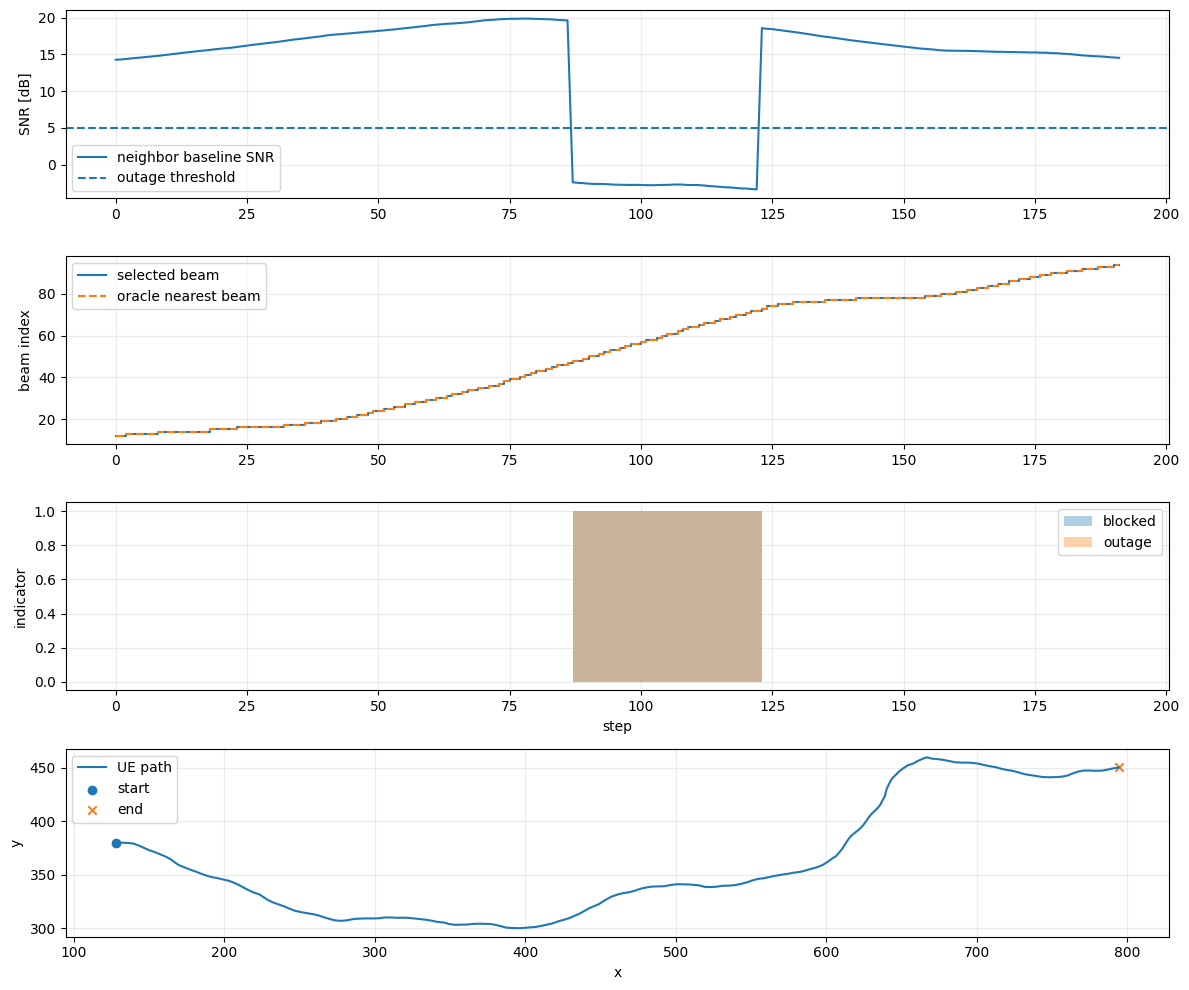

Saved CSV : baseline_outputs/neighbor_baseline_stochastic_log.csv
Saved plot: baseline_outputs/neighbor_baseline_stochastic_plot.png


In [7]:
write_csv(logs, CSV_PATH)
plot_logs(logs, save_path=FIG_PATH)

print(f"Saved CSV : {CSV_PATH}")
print(f"Saved plot: {FIG_PATH}")

## Quick inspection

In [8]:
# Show the first few logged decision epochs.
for row in logs[:5]:
    print(
        f"t={row['t']:3d} "
        f"beam={row['selected_beam_idx']:3d} "
        f"oracle={row['oracle_beam_idx']:3d} "
        f"snr={row['snr_db']:7.2f} dB "
        f"blocked={row['blocked']} "
        f"outage={row['outage']}"
    )

t=  0 beam= 12 oracle= 12 snr=  14.28 dB blocked=False outage=False
t=  1 beam= 12 oracle= 12 snr=  14.31 dB blocked=False outage=False
t=  2 beam= 13 oracle= 13 snr=  14.39 dB blocked=False outage=False
t=  3 beam= 13 oracle= 13 snr=  14.45 dB blocked=False outage=False
t=  4 beam= 13 oracle= 13 snr=  14.52 dB blocked=False outage=False
